# ****Лабораторная работа №2****: ***Сегментация дорог с Аэрофотоснимков***

## Датасет

In [81]:
from pathlib import Path
from typing import Optional, List
import numpy as np
import torch
from torch.utils.data import Dataset
import tifffile
import torchvision.transforms as T
import random


class RoadsDataset(Dataset):
    def __init__(
        self,
        root: str,
        split: str = "train",
        image_size: int = 512,
        return_paths: bool = False,
        binarize_mask: bool = True,
    ):
        super().__init__()
        self.root = Path(root)
        self.split = split
        self.image_size = image_size
        self.return_paths = return_paths
        self.binarize_mask = binarize_mask

        self.images_dir = self.root / split
        self.masks_dir = self.root / f"{split}_labels"

        image_paths = sorted(self.images_dir.glob("*.tiff"))
        self.image_paths: List[Path] = []
        self.mask_map = {}

        for img_path in image_paths:
            mask_path = self.masks_dir / f"{img_path.stem}.tif"
            if mask_path.exists():
                self.image_paths.append(img_path)
                self.mask_map[img_path.stem] = mask_path

        resize_size = int(image_size * 1.75)

        if split == "train":
            self.image_transform = T.Compose([
                T.ToTensor(),
                T.Resize(resize_size, antialias=True),
                T.RandomCrop(image_size),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5)
            ])
            self.mask_transform = T.Compose([
                T.ToTensor(),
                T.Resize(resize_size, antialias=True),
                T.RandomCrop(image_size),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
            ])
        else:  # val / test
            self.image_transform = T.Compose([
                T.ToTensor(),
                T.Resize(resize_size, antialias=True),
                T.CenterCrop(image_size)
            ])
            self.mask_transform = T.Compose([
                T.ToTensor(),
                T.Resize(resize_size, antialias=True),
                T.CenterCrop(image_size),
            ])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        mask_path = self.mask_map[img_path.stem]

        image = tifffile.imread(str(img_path))
        mask = tifffile.imread(str(mask_path))

        if self.binarize_mask:
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.uint8)

        # Синхронизация аугментаций
        if self.split == "train":
            seed = random.randint(0, 2**32 - 1)
            torch.manual_seed(seed)
            image = self.image_transform(image)

            torch.manual_seed(seed)
            mask = self.mask_transform(mask)
        else:
            image = self.image_transform(image)
            mask = self.mask_transform(mask)

        mask = mask.squeeze(0).unsqueeze(0).float()

        if self.return_paths:
            return image, mask, str(img_path)
        return image, mask

In [82]:
from torch.utils.data import DataLoader

image_size = 512
root = "roads_dataset/tiff"

train_ds = RoadsDataset(root=root,
                        split="train",
                        image_size=image_size)

val_ds   = RoadsDataset(root=root, 
                        split="val",   
                        image_size=image_size)

test_ds  = RoadsDataset(root=root, 
                        split="test",  
                        image_size=image_size)

image, mask = train_ds[0]
print(f"Размер изображения: {image.shape}")
print(f"Размер маски: {mask.shape}")

print(f"Train размер: {len(train_ds)}")
print(f"Val размер: {len(val_ds)}")
print(f"Test размер: {len(test_ds)}")


Размер изображения: torch.Size([3, 512, 512])
Размер маски: torch.Size([1, 512, 512])
Train размер: 1108
Val размер: 14
Test размер: 49


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03277836..1.0000002].


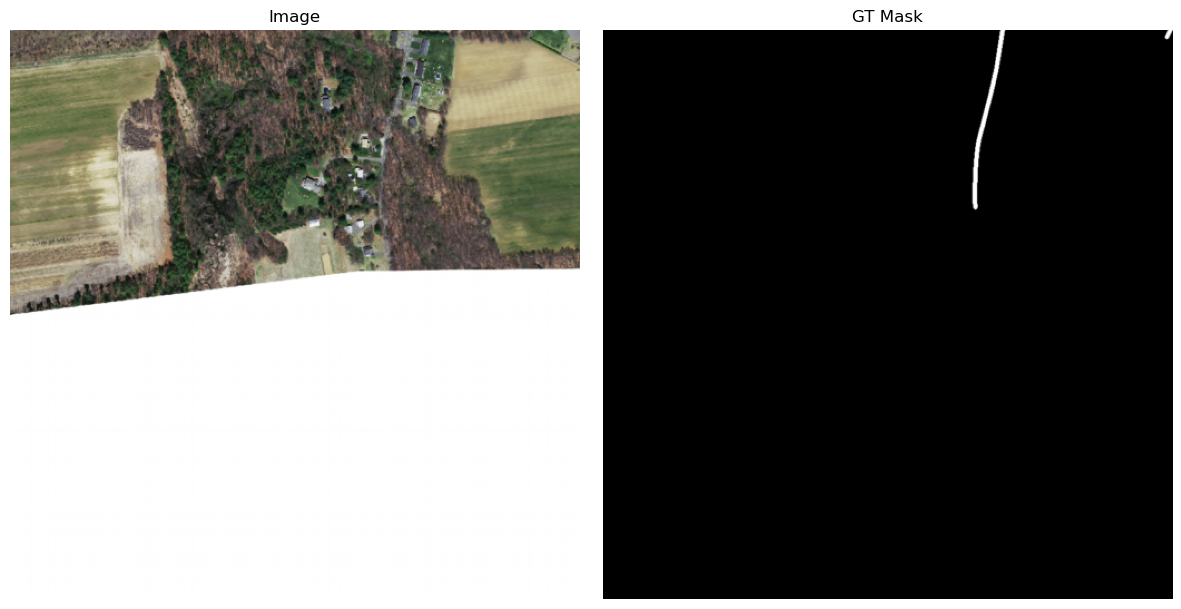

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([1, 512, 512])


In [109]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

image, mask = train_ds[0]


image_vis = image.permute(1, 2, 0).cpu().numpy()
mask_vis = mask.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_vis, cmap="gray")
axes[1].set_title("GT Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape if hasattr(image, "shape") else type(image))
print("Mask shape:", mask.shape if hasattr(mask, "shape") else type(mask))

# Модель, loss, optimizer

In [10]:
import torch
import torch.nn as nn
from tqdm import tqdm
import os

EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"device: {DEVICE}")

device: cuda


In [11]:
import segmentation_models_pytorch as smp
import torch.optim as optim

model = smp.Unet(
    encoder_name="vgg16_bn", 
    encoder_weights="imagenet", 
    in_channels=3,
    classes=1, 
    activation=None,
    decoder_interpolation="bilinear",
    decoder_use_batchnorm=True
).to(DEVICE)

KeyboardInterrupt: 

In [ ]:
criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3, 
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1, 
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

# Train цикл

In [ ]:
def train_epoch():
    model.train()
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item()
    
    return running_loss / len(train_loader)

@torch.no_grad()
def validate():
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    
    for images, masks in tqdm(val_loader, desc="Validation", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        
        logits = model(images)
        loss = criterion(logits, masks)
        
        running_loss += loss.item()
        
        tp, fp, fn, tn = smp.metrics.get_stats(logits, masks.long(), mode='binary', threshold=0.5)
        dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction='micro')
        running_hard_dice += dice.item()
    
    avg_loss = running_loss / len(val_loader)
    avg_f1 = running_hard_dice / len(val_loader)
    
    print(f"Dice (f1-score): {avg_f1:.4f}")
    return avg_loss, avg_f1

In [ ]:
best_dice = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch()
    val_loss, val_dice = validate()
    
    scheduler.step(val_dice)
    
    print(f"Epoch {epoch+1:3d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}")
    
    if val_dice > best_dice:
        best_dice = val_dice
        print(f"Обновлен best_dice: {best_dice}")
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'dice': best_dice,
        }, os.path.join(SAVE_DIR, "best_unet_vgg16bn_dice.pth"))

print(f"\nЛучший Dice на валидации = {best_dice:.4f} (эпоха {best_epoch})")

100%|██████████| 277/277 [01:55<00:00,  2.39it/s]
e:\Anaconda\envs\pytorch-dl\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


   Soft Dice: 0.4962 | Hard Dice: 0.5790
Epoch   1 | Train Loss: 0.7623 | Val Loss: 0.5038
Обновлен best_dice: 0.579025149345398


100%|██████████| 277/277 [01:53<00:00,  2.44it/s]


   Soft Dice: 0.5894 | Hard Dice: 0.6121
Epoch   2 | Train Loss: 0.5121 | Val Loss: 0.4106
Обновлен best_dice: 0.6121114790439606


100%|██████████| 277/277 [01:55<00:00,  2.41it/s]


...

   Soft Dice: 0.6865 | Hard Dice: 0.6872
Epoch  48 | Train Loss: 0.3597 | Val Loss: 0.3135


100%|██████████| 277/277 [01:52<00:00,  2.47it/s]


   Soft Dice: 0.6760 | Hard Dice: 0.6766
Epoch  49 | Train Loss: 0.3579 | Val Loss: 0.3240


100%|██████████| 277/277 [01:50<00:00,  2.50it/s]
                                                         

   Soft Dice: 0.7036 | Hard Dice: 0.7050
Epoch  50 | Train Loss: 0.3603 | Val Loss: 0.2964

Лучший Dice на валидации = 0.7114 (эпоха 21)


# Тест

In [ ]:
import random
import matplotlib.pyplot as plt

model.eval()
test_dice = 0
num_samples = 0

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        image, mask = image.to(DEVICE), mask.to(DEVICE)
        
        output = model(image)
        
        loss = criterion(output, mask)
        dice_score = 1 - loss.item()
        test_dice += dice_score
        num_samples += 1

# Вывод среднего Dice Score
avg_test_dice = test_dice / num_samples
print(f'Average Dice Score on Test Set: {avg_test_dice:.4f}')


Average Dice Score on Test Set: 0.7260
